# CERN Dimuon Verileri ile Makine Öğrenmesi

**Final Medium Projesi**

Bu projede CERN Open Data Portal'da yayımlanan dimuon olayları incelenmektedir.
Amaç; veri setini tanımak, temel keşifsel veri analizi yapmak, momentumları 3B
olarak görselleştirmek ve veri setindeki **`Type2`** etiketini basit makine
öğrenmesi yöntemleriyle sınıflandırmaktır.

Kullanılan modeller:
- Logistic Regression
- K-Nearest Neighbors (KNN)

> Not: Bu çalışma eğitim amaçlıdır; yeni bir fizik keşfi iddiası taşımaz.

## 1. Kütüphaneler ve veri setinin yüklenmesi
Veri dosyası doğrudan CERN Open Data bağlantısından okunmaktadır.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

url = "https://opendata.cern.ch/record/700/files/MuRun2010B_0.csv"

df_original = pd.read_csv(url)
df = df_original.copy()

df.head()

,Run,Event,Type1,E1,px1,py1,pz1,pt1,eta1,phi1,...,Type2,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
0,146436,90830792,G,19.17120,3.817130,9.04323,-16.46730,9.81583,-1.289420,1.171390,...,T,5.43984,-0.362592,2.626990,-4.748490,2.65189,-1.345870,1.707960,1,2.73205
1,146436,90862225,G,12.94350,5.125790,-3.98369,-11.19730,6.49180,-1.313350,-0.660674,...,G,11.86360,4.789840,-6.262220,-8.864340,7.88403,-0.966622,-0.917841,1,3.10256
2,146436,90644850,G,12.39990,-0.849742,9.40110,8.04015,9.43943,0.772580,1.660940,...,G,8.55532,-4.851550,6.976960,-0.983229,8.49797,-0.115445,2.178410,-1,9.41149
3,146436,90678594,G,17.81320,-1.959590,2.80531,17.48110,3.42195,2.333500,2.180530,...,G,9.42174,4.365230,0.168017,8.347130,4.36846,1.403000,0.038471,1,7.74702
4,146436,90686690,G,7.95664,7.097000,-1.31646,3.34613,7.21806,0.448399,-0.183411,...,T,5.44467,-1.341760,1.386470,5.090250,1.92941,1.697380,2.339810,-1,8.67727


## 2. Veri setini tanıma
Önce veri setinin boyutu, sütunları, veri tipleri ve temel istatistikleri incelenir.

In [24]:
print("Veri seti boyutu:", df.shape)
print("\nSütunlar:")
print(df.columns.tolist())

Veri seti boyutu: (10000, 21)

Sütunlar:
['Run', 'Event', 'Type1', 'E1', 'px1 ', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'Type2', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Run     10000 non-null  int64  
 1   Event   10000 non-null  int64  
 2   Type1   10000 non-null  object 
 3   E1      10000 non-null  float64
 4   px1     10000 non-null  float64
 5   py1     10000 non-null  float64
 6   pz1     10000 non-null  float64
 7   pt1     10000 non-null  float64
 8   eta1    10000 non-null  float64
 9   phi1    10000 non-null  float64
 10  Q1      10000 non-null  int64  
 11  Type2   10000 non-null  object 
 12  E2      10000 non-null  float64
 13  px2     10000 non-null  float64
 14  py2     10000 non-null  float64
 15  pz2     10000 non-null  float64
 16  pt2     10000 non-null  float64
 17  eta2    10000 non-null  float64
 18  phi2    10000 non-null  float64
 19  Q2      10000 non-null  int64  
 20  M       10000 non-null  float64
dtypes: float64(15), int64(4), object(2)


In [26]:
df.describe()

,Run,Event,E1,px1,py1,pz1,pt1,eta1,phi1,Q1,E2,px2,py2,pz2,pt2,eta2,phi2,Q2,M
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000
mean,147470.20050,2.585989e+08,18.662200,0.039386,-0.226131,-0.336185,7.850492,-0.090415,-0.053117,0.008000,8.927213,0.070896,0.195626,0.728306,4.685848,0.102000,0.025983,-0.00440,9.757237
std,720.59589,3.584407e+08,41.820337,9.404849,8.317013,44.039132,9.800008,1.503689,1.817625,1.000018,26.641157,8.583319,6.735086,25.881175,9.854888,1.467094,1.813348,1.00004,9.609037
min,146436.00000,4.955803e+07,2.829370,-119.654000,-89.026100,-1338.520000,1.065600,-2.451230,-3.140980,-1.000000,2.506870,-48.442500,-87.771600,-1232.880000,0.578608,-2.471670,-3.141320,-1.00000,2.000170
25%,147048.00000,6.802140e+07,8.704340,-3.789850,-3.884350,-11.060975,4.138167,-1.513080,-1.629532,-1.000000,4.571835,-1.875652,-1.750695,-4.210212,1.607568,-1.301722,-1.557443,-1.00000,3.125805
50%,147115.00000,1.476177e+08,13.069700,0.031544,-0.235046,-1.510470,6.085880,-0.183893,-0.080704,1.000000,6.319415,-0.035108,0.046293,1.069450,3.807975,0.183287,0.041791,-1.00000,7.361005
75%,148058.00000,2.563194e+08,21.797675,3.643635,3.604903,9.967065,9.831188,1.387848,1.506315,1.000000,9.634502,1.903113,2.014972,5.200077,5.533938,1.470357,1.614560,1.00000,12.783000
max,149181.00000,1.587040e+09,3384.430000,593.661000,385.344000,3309.590000,707.759000,2.507780,3.141450,1.000000,2239.410000,740.575000,412.516000,2072.760000,847.716000,2.485670,3.141320,1.00000,109.201000


### Değişkenlerin kısa açıklaması

- `Run`, `Event`: Olay kimlik bilgileri.
- `Type1`, `Type2`: Veri setindeki iki müon için verilen tip etiketleri.
- `E1`, `E2`: İki müonun enerjileri.
- `px1`, `py1`, `pz1`, `px2`, `py2`, `pz2`: Momentum bileşenleri.
- `pt1`, `pt2`: Enine momentum.
- `eta1`, `eta2`: Pseudorapidity.
- `phi1`, `phi2`: Azimut açısı.
- `Q1`, `Q2`: Elektrik yükleri.
- `M`: İki müondan hesaplanan invariant mass (değişmez kütle).

Bu veri dosyasında `Type1` bütün satırlarda `G` olduğu için sınıflandırma hedefi
olarak uygun değildir. `Type2` ise `G` ve `T` olmak üzere iki sınıf içerdiğinden
makine öğrenmesi hedefi olarak kullanılacaktır.

## 3. Veri kalite kontrolü
Eksik değerler ve tekrar eden kayıtlar kontrol edilir.

In [27]:
print("Eksik değer sayıları:")
print(df.isnull().sum())

print("\nToplam eksik değer:", int(df.isnull().sum().sum()))
print("Duplicate kayıt sayısı:", int(df.duplicated().sum()))

Eksik değer sayıları:
Run      0
Event    0
Type1    0
E1       0
px1      0
py1      0
pz1      0
pt1      0
eta1     0
phi1     0
Q1       0
Type2    0
E2       0
px2      0
py2      0
pz2      0
pt2      0
eta2     0
phi2     0
Q2       0
M        0
dtype: int64

Toplam eksik değer: 0
Duplicate kayıt sayısı: 0


In [28]:
once = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print("Temizlik öncesi satır sayısı:", once)
print("Temizlik sonrası satır sayısı:", after)

Temizlik öncesi satır sayısı: 10000
Temizlik sonrası satır sayısı: 10000


## 4. `Type1` ve `Type2` sınıf dağılımları

Önce iki tip sütunu incelenir. `Type1` tek sınıflı olduğu için model hedefi yapılmaz.
`Type2` ise iki sınıfa sahip olduğu için hedef değişken olarak seçilir.

In [29]:
print("Type1 dağılımı:")
print(df["Type1"].value_counts())

print("\nType2 dağılımı:")
print(df["Type2"].value_counts())

Type1 dağılımı:
Type1
G    10000
Name: count, dtype: int64

Type2 dağılımı:
Type2
G    5139
T    4861
Name: count, dtype: int64


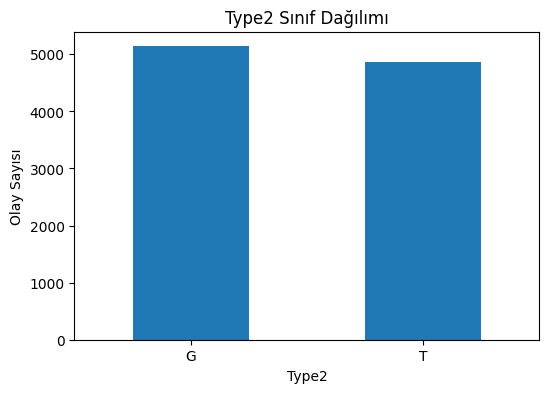

In [30]:
type2_counts = df["Type2"].value_counts()

plt.figure(figsize=(6, 4))
type2_counts.plot(kind="bar")
plt.title("Type2 Sınıf Dağılımı")
plt.xlabel("Type2")
plt.ylabel("Olay Sayısı")
plt.xticks(rotation=0)
plt.show()

## 5. Keşifsel Veri Analizi (EDA)

İlk olarak invariant mass (`M`) dağılımı incelenir.

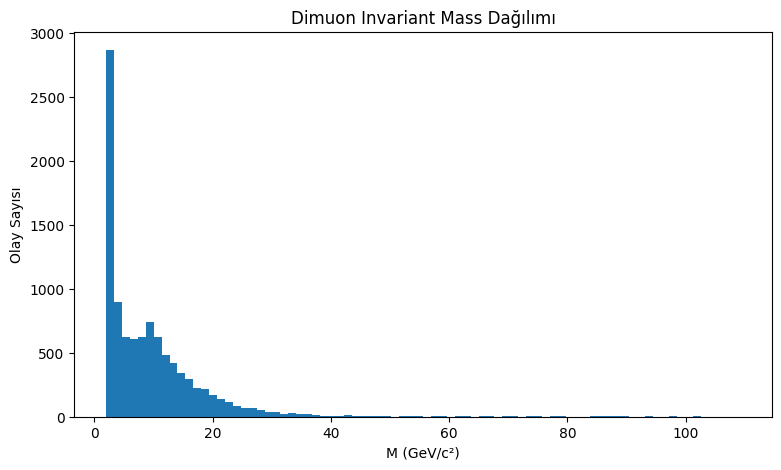

In [31]:
plt.figure(figsize=(9, 5))
plt.hist(df["M"].dropna(), bins=80)
plt.title("Dimuon Invariant Mass Dağılımı")
plt.xlabel("M (GeV/c²)")
plt.ylabel("Olay Sayısı")
plt.show()

### `Type2` sınıflarına göre invariant mass
`G` ve `T` sınıflarının `M` dağılımları aynı grafikte karşılaştırılır.

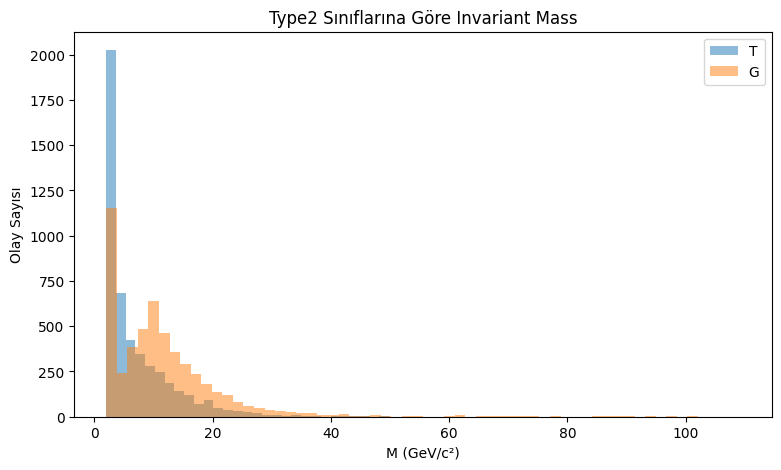

In [32]:
plt.figure(figsize=(9, 5))

for event_type in df["Type2"].dropna().unique():
    values = df.loc[df["Type2"] == event_type, "M"].dropna()
    plt.hist(values, bins=60, alpha=0.5, label=str(event_type))

plt.title("Type2 Sınıflarına Göre Invariant Mass")
plt.xlabel("M (GeV/c²)")
plt.ylabel("Olay Sayısı")
plt.legend()
plt.show()

### Enine momentum dağılımları
İki müonun `pt1` ve `pt2` değerleri karşılaştırılır.

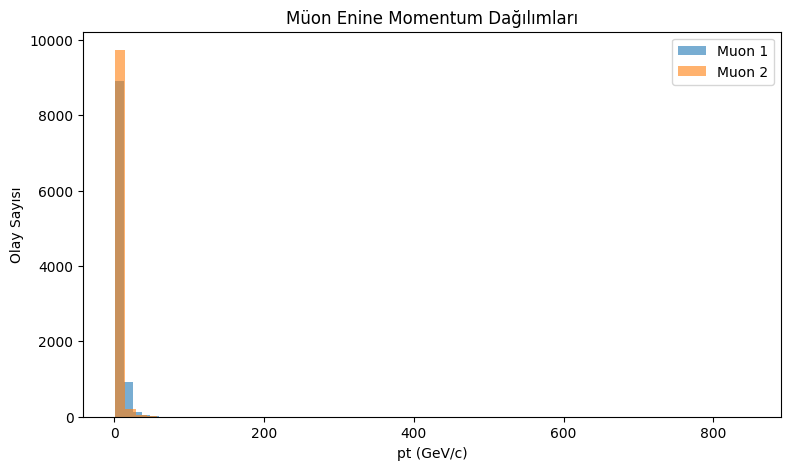

In [33]:
plt.figure(figsize=(9, 5))
plt.hist(df["pt1"].dropna(), bins=60, alpha=0.6, label="Muon 1")
plt.hist(df["pt2"].dropna(), bins=60, alpha=0.6, label="Muon 2")
plt.title("Müon Enine Momentum Dağılımları")
plt.xlabel("pt (GeV/c)")
plt.ylabel("Olay Sayısı")
plt.legend()
plt.show()

## 6. 3B Collision / Momentum Görselleştirmesi

Tek bir dimuon olayında iki müonun momentum vektörleri `(px, py, pz)` uzayında
gösterilir. Bu, dedektör geometrisinin tam bir simülasyonu değil; momentum
vektörlerinin öğretici bir 3B görselleştirmesidir.

In [34]:
for col in df.columns:
    print(repr(col))

'Run'
'Event'
'Type1'
'E1'
'px1 '
'py1'
'pz1'
'pt1'
'eta1'
'phi1'
'Q1'
'Type2'
'E2'
'px2'
'py2'
'pz2'
'pt2'
'eta2'
'phi2'
'Q2'
'M'


In [35]:
df.columns = df.columns.str.strip()

In [36]:
print(df.columns.tolist())

['Run', 'Event', 'Type1', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1', 'phi1', 'Q1', 'Type2', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2', 'Q2', 'M']


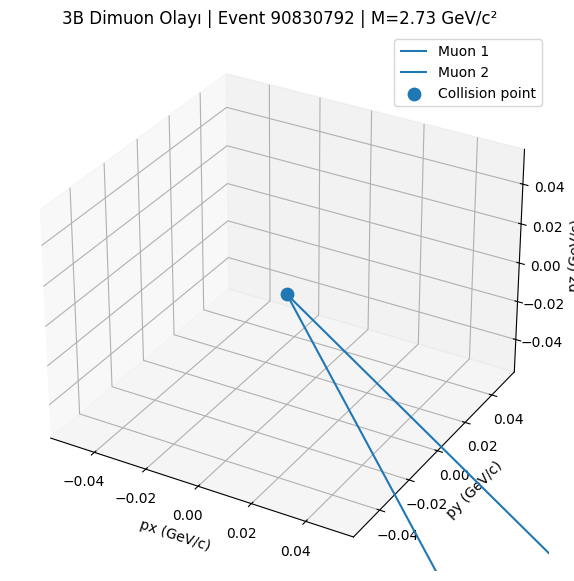

In [37]:
event = df.iloc[0]

fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection="3d")

ax.quiver(
    0, 0, 0,
    event["px1"], event["py1"], event["pz1"],
    arrow_length_ratio=0.10,
    label="Muon 1"
)

ax.quiver(
    0, 0, 0,
    event["px2"], event["py2"], event["pz2"],
    arrow_length_ratio=0.10,
    label="Muon 2"
)

ax.scatter([0], [0], [0], s=80, label="Collision point")

ax.set_xlabel("px (GeV/c)")
ax.set_ylabel("py (GeV/c)")
ax.set_zlabel("pz (GeV/c)")

ax.set_title(
    f"3B Dimuon Olayı | Event {int(event['Event'])} | "
    f"M={event['M']:.2f} GeV/c²"
)

ax.legend()
plt.show()

## 7. Makine öğrenmesi için veri hazırlama

Hedef değişken **`Type2`**'dir.

Kimlik sütunları (`Run`, `Event`) kullanılmaz. `Type1` de tek bir değer içerdiği
için özellik olarak kullanılmaz. Modelde sayısal fiziksel değişkenler kullanılır.

Ek olarak, iki müonun yüklerinin zıt olup olmadığını gösteren `is_opposite`
özelliği oluşturulur.

In [38]:
df_ml = df.copy()

df_ml["is_opposite"] = (df_ml["Q1"] != df_ml["Q2"]).astype(int)

feature_cols = [
    "E1", "px1", "py1", "pz1", "pt1", "eta1", "phi1", "Q1",
    "E2", "px2", "py2", "pz2", "pt2", "eta2", "phi2", "Q2",
    "M", "is_opposite"
]

X = df_ml[feature_cols].copy()
y_raw = df_ml["Type2"].copy()

print("Özellik sayısı:", X.shape[1])
print("Eksik özellik değeri:", int(X.isnull().sum().sum()))
print("\nHedef dağılımı:")
print(y_raw.value_counts())

Özellik sayısı: 18
Eksik özellik değeri: 0

Hedef dağılımı:
Type2
G    5139
T    4861
Name: count, dtype: int64


In [39]:
ml_data = pd.concat([X, y_raw.rename("Type2")], axis=1).dropna().copy()

X = ml_data[feature_cols]
y_raw = ml_data["Type2"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_raw)

class_map = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("Sınıf kodları:", class_map)

Sınıf kodları: {'G': np.int64(0), 'T': np.int64(1)}


## 8. Train/Test ayrımı ve ölçeklendirme

Veri %80 eğitim, %20 test olarak ayrılır. Sınıf oranlarının korunması için
`stratify=y` kullanılır. Ölçekleyici yalnızca eğitim verisine fit edilir.

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Eğitim örneği:", X_train.shape[0])
print("Test örneği:", X_test.shape[0])

Eğitim örneği: 8000
Test örneği: 2000


## 9. Model 1 — Logistic Regression

In [41]:
log_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

log_pred = log_model.predict(X_test_scaled)
log_accuracy = accuracy_score(y_test, log_pred)

print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")
print()
print(
    classification_report(
        y_test,
        log_pred,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Accuracy: 0.8700

              precision    recall  f1-score   support

           G       0.88      0.87      0.87      1028
           T       0.86      0.87      0.87       972

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



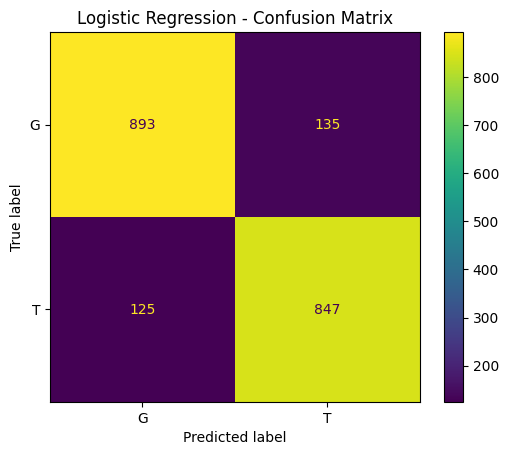

In [42]:
cm_log = confusion_matrix(y_test, log_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

## 10. Model 2 — KNN
Karşılaştırma amacıyla ikinci basit model olarak KNN kullanılır.

In [43]:
knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)

print(f"KNN Accuracy: {knn_accuracy:.4f}")
print()
print(
    classification_report(
        y_test,
        knn_pred,
        target_names=label_encoder.classes_
    )
)

KNN Accuracy: 0.8965

              precision    recall  f1-score   support

           G       0.89      0.92      0.90      1028
           T       0.91      0.87      0.89       972

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000



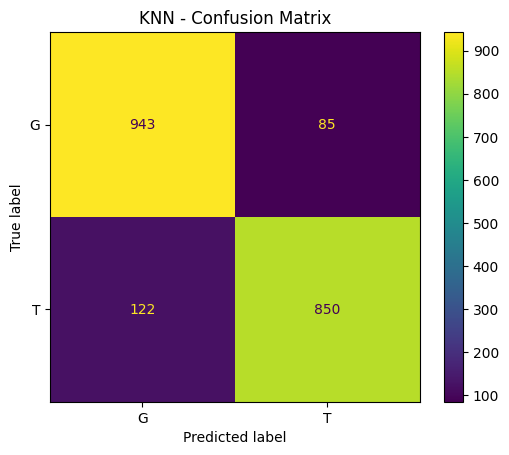

In [44]:
cm_knn = confusion_matrix(y_test, knn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=label_encoder.classes_
)

disp.plot()
plt.title("KNN - Confusion Matrix")
plt.show()

## 11. Modellerin karşılaştırılması

                 Model  Accuracy
1                  KNN    0.8965
0  Logistic Regression    0.8700


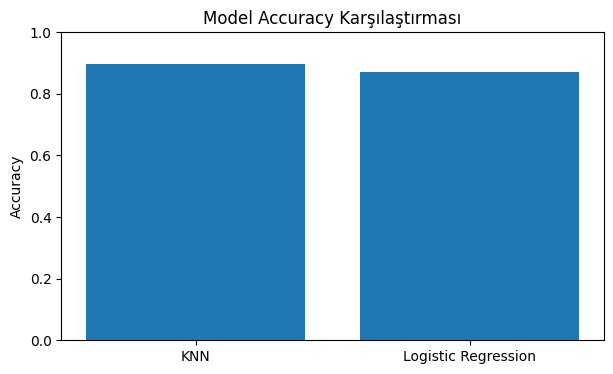

In [45]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN"],
    "Accuracy": [log_accuracy, knn_accuracy]
}).sort_values("Accuracy", ascending=False)

print(model_results)

plt.figure(figsize=(7, 4))
plt.bar(model_results["Model"], model_results["Accuracy"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Karşılaştırması")
plt.show()

## 12. Logistic Regression katsayıları

Bu bölüm modelin hangi girdilere daha büyük katsayılar verdiğini gösterir.
Katsayı büyüklüğü tek başına fiziksel nedensellik veya bilimsel önem anlamına gelmez.

   Feature  Coefficient
12     pt2    -7.174179
8       E2     4.156744
4      pt1     2.520195
11     pz2     1.447550
16       M    -0.972058
0       E1    -0.958031
9      px2     0.854010
13    eta2    -0.594596
10     py2     0.506783
3      pz1    -0.491766


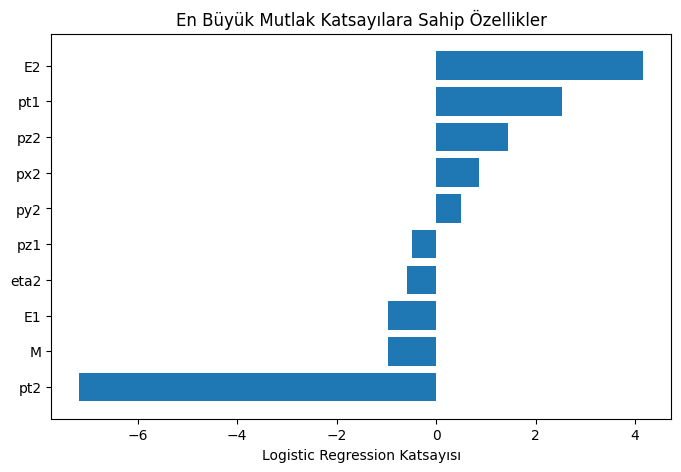

In [46]:
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": log_model.coef_[0]
})

coef_df["AbsCoefficient"] = coef_df["Coefficient"].abs()
coef_df = coef_df.sort_values("AbsCoefficient", ascending=False)

print(coef_df[["Feature", "Coefficient"]].head(10))

top_coef = coef_df.head(10).sort_values("Coefficient")

plt.figure(figsize=(8, 5))
plt.barh(top_coef["Feature"], top_coef["Coefficient"])
plt.xlabel("Logistic Regression Katsayısı")
plt.title("En Büyük Mutlak Katsayılara Sahip Özellikler")
plt.show()

## 13. Sonuç

Bu projede:

- CERN dimuon veri setinin yapısı incelendi.
- Eksik ve tekrar eden kayıt kontrolleri yapıldı.
- `Type1` sütununun tüm kayıtlarda `G` olduğu görüldü.
- `Type2` sütununda `G` ve `T` sınıfları bulunduğu için sınıflandırma hedefi olarak `Type2` seçildi.
- Invariant mass ve momentum dağılımları görselleştirildi.
- Bir dimuon olayının momentum vektörleri 3B olarak gösterildi.
- Logistic Regression ve KNN modelleri eğitildi.
- Accuracy, classification report ve confusion matrix ile modeller değerlendirildi.

Medium yazısında notebook çalıştırıldıktan sonra elde edilen **gerçek accuracy ve metrikler**
yorumlanmalıdır. Model başarısı yeni bir fizik keşfi anlamına gelmez.

## 14. Medium yazısı için önerilen bölüm sırası

1. Giriş ve projenin amacı
2. CERN dimuon veri seti
3. Veri hazırlama ve kalite kontrolü
4. `Type1` ve `Type2` incelemesi
5. Keşifsel veri analizi
6. 3B momentum görselleştirmesi
7. Logistic Regression ve KNN
8. Model sonuçları ve değerlendirme metrikleri
9. Sonuç ve sınırlılıklar
10. GitHub proje bağlantısı